In [2]:
from pathlib import Path

CONFIG_DIR = Path("/home/yli94/CLIF/OHCA-RL/config")
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

config_text = """{
    "site_name": "mimic",
    "tables_path": "/home/yli94/CLIF_MIMIC",
    "file_type": "parquet",
    "timezone": "US/Eastern"
}
"""

config_path = CONFIG_DIR / "config.json"
config_path.write_text(config_text)

print(f"Wrote {config_path}")
print(config_path.read_text())

# Verify the MIMIC CLIF tables path exists
tables_path = Path("/home/yli94/CLIF_MIMIC")
print(f"\nTables path exists: {tables_path.exists()}")
if tables_path.exists():
    print("First 10 files:")
    for p in sorted(tables_path.iterdir())[:10]:
        print(f"  {p.name}")

Wrote /home/yli94/CLIF/OHCA-RL/config/config.json
{
    "site_name": "mimic",
    "tables_path": "/home/yli94/CLIF_MIMIC",
    "file_type": "parquet",
    "timezone": "US/Eastern"
}


Tables path exists: True
First 10 files:
  clif_adt.parquet
  clif_code_status.parquet
  clif_crrt_therapy.parquet
  clif_ecmo_mcs.parquet
  clif_hospital_diagnosis.parquet
  clif_hospitalization.parquet
  clif_labs.parquet
  clif_medication_admin_continuous.parquet
  clif_medication_admin_intermittent.parquet
  clif_patient.parquet


In [3]:
import sys, json, logging
from pathlib import Path
import pandas as pd
import duckdb
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ── Paths (anchored to the repo root, NOT the notebook directory) ──
PROJECT_ROOT = Path("/home/yli94/CLIF/OHCA-RL")
CODE_DIR     = PROJECT_ROOT / "code"
CONFIG_DIR   = PROJECT_ROOT / "config"
OUT_DIR      = PROJECT_ROOT / "output" / "intermediate"
FINAL_DIR    = PROJECT_ROOT / "output" / "final"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# Make code/utils.py importable
sys.path.insert(0, str(CODE_DIR))
if "utils" in sys.modules:
    del sys.modules["utils"]
import utils
print("utils loaded from:", utils.__file__)

# Load site config
with open(CONFIG_DIR / "config.json") as f:
    site_config = json.load(f)
SITE_NAME   = site_config["site_name"]
TABLES_PATH = site_config["tables_path"]
FILE_TYPE   = site_config["file_type"]
TIMEZONE    = site_config["timezone"]

# Sanity
assert Path(TABLES_PATH).exists(), f"tables_path not found: {TABLES_PATH}"

# clifpy
import clifpy
from clifpy import Hospitalization, HospitalDiagnosis, Adt

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("00_cohort")

print(f"\nPython         : {sys.version.split()[0]}")
print(f"Executable     : {sys.executable}")
print(f"clifpy version : {clifpy.__version__}")
print(f"Site           : {SITE_NAME}")
print(f"Tables path    : {TABLES_PATH}")
print(f"Timezone       : {TIMEZONE}")

utils loaded from: /home/yli94/CLIF/OHCA-RL/code/utils.py

Python         : 3.13.13
Executable     : /home/yli94/CLIF/OHCA-RL/.venv/bin/python3
clifpy version : 0.3.9
Site           : mimic
Tables path    : /home/yli94/CLIF_MIMIC
Timezone       : US/Eastern


In [4]:
hosp_obj = Hospitalization.from_file(data_directory=TABLES_PATH, filetype=FILE_TYPE, timezone=TIMEZONE)
dx_obj   = HospitalDiagnosis.from_file(data_directory=TABLES_PATH, filetype=FILE_TYPE, timezone=TIMEZONE)
adt_obj  = Adt.from_file(data_directory=TABLES_PATH, filetype=FILE_TYPE, timezone=TIMEZONE)

hosp_df = hosp_obj.df
dx_df   = dx_obj.df
adt_df  = adt_obj.df

# Normalize *_id columns to str (sites store as int or str inconsistently)
for _df in (hosp_df, dx_df, adt_df):
    for _col in _df.columns:
        if _col.endswith("_id"):
            _df[_col] = _df[_col].astype(str)

# Register tables in DuckDB for SQL queries
con = duckdb.connect()
con.register("hosp_tbl", hosp_df)
con.register("dx_tbl",   dx_df)
con.register("adt_tbl",  adt_df)

print(f"hospitalization     : {len(hosp_df):,} rows")
print(f"  cols: {list(hosp_df.columns)}")
print()
print(f"hospital_diagnosis  : {len(dx_df):,} rows")
print(f"  cols: {list(dx_df.columns)}")
print()
print(f"adt                 : {len(adt_df):,} rows")
print(f"  cols: {list(adt_df.columns)}")

📢 Initialized hospitalization table
📢 Data directory: /home/yli94/CLIF_MIMIC
📢 File type: parquet
📢 Timezone: US/Eastern
📢 Output directory: /home/yli94/CLIF/OHCA-RL/notebook/output
📢 Loaded schema from /home/yli94/CLIF/OHCA-RL/.venv/lib/python3.13/site-packages/clifpy/schemas/hospitalization_schema.yaml
📢 Loaded outlier configuration
📢 Initialized hospital_diagnosis table
📢 Data directory: /home/yli94/CLIF_MIMIC
📢 File type: parquet
📢 Timezone: US/Eastern
📢 Output directory: /home/yli94/CLIF/OHCA-RL/notebook/output
📢 Loaded schema from /home/yli94/CLIF/OHCA-RL/.venv/lib/python3.13/site-packages/clifpy/schemas/hospital_diagnosis_schema.yaml
📢 Loaded outlier configuration
📢 Initialized adt table
📢 Data directory: /home/yli94/CLIF_MIMIC
📢 File type: parquet
📢 Timezone: US/Eastern
📢 Output directory: /home/yli94/CLIF/OHCA-RL/notebook/output
📢 Loaded schema from /home/yli94/CLIF/OHCA-RL/.venv/lib/python3.13/site-packages/clifpy/schemas/adt_schema.yaml
📢 Loaded outlier configuration
hospita

In [5]:
ICD_PREFIXES = ["i460", "i461", "i462", "i468", "i469", "i4900", "i4901"]
ICD_DESCRIPTIONS = {
    "i460":  "Cardiac arrest with successful resuscitation",
    "i461":  "Sudden cardiac death, so described",
    "i462":  "Cardiac arrest due to underlying cardiac condition",
    "i468":  "Cardiac arrest due to other underlying condition",
    "i469":  "Cardiac arrest, cause unspecified",
    "i4900": "Ventricular fibrillation",
    "i4901": "Ventricular flutter",
}
_icd_filter = "(" + " OR ".join(f"dx_clean LIKE '{c}%'" for c in ICD_PREFIXES) + ")"

cohort_v2 = con.execute(f"""
    WITH dx_cleaned AS (
        SELECT
            d.hospitalization_id,
            d.diagnosis_code,
            LOWER(REPLACE(d.diagnosis_code, '.', '')) AS dx_clean,
            COALESCE(CAST(d.poa_present AS INT), 0)   AS poa_present
        FROM dx_tbl d
    )
    SELECT DISTINCT
        h.patient_id,
        dc.hospitalization_id,
        dc.diagnosis_code,
        dc.dx_clean,
        dc.poa_present,
        CASE
            WHEN dc.poa_present = 1 THEN 'ohca'
            WHEN dc.poa_present = 0 THEN 'ihca'
            ELSE 'unknown'
        END AS arrest_type,
        LOWER(hc.discharge_category) AS discharge_category,
        CASE WHEN LOWER(hc.discharge_category) = 'expired'
             THEN 'non-survivor' ELSE 'survivor' END AS survival_status
    FROM dx_cleaned dc
    INNER JOIN hosp_tbl hc ON dc.hospitalization_id = hc.hospitalization_id
    INNER JOIN (SELECT DISTINCT patient_id, hospitalization_id FROM hosp_tbl) h
        ON dc.hospitalization_id = h.hospitalization_id
    WHERE {_icd_filter}
""").fetchdf()

# Tag each row with an ICD description
cohort_v2["icd_description"] = cohort_v2["dx_clean"].apply(
    lambda c: next((desc for p, desc in ICD_DESCRIPTIONS.items() if c.startswith(p)), "Unknown")
)

# STROBE tracker — start fresh each notebook run
strobe_counts = {
    "1_all_cardiac_arrest_patients":   cohort_v2["patient_id"].nunique(),
    "1_all_cardiac_arrest_encounters": cohort_v2["hospitalization_id"].nunique(),
}

print(f"After Step 1 — cardiac arrest by ICD I46.x / I49.0x:")
print(f"  Patients   : {strobe_counts['1_all_cardiac_arrest_patients']:,}")
print(f"  Encounters : {strobe_counts['1_all_cardiac_arrest_encounters']:,}")
print(f"\nICD breakdown (encounters):")
print(cohort_v2.drop_duplicates(subset=["hospitalization_id", "dx_clean"])
      ["icd_description"].value_counts().to_string())
print(f"\nDischarge distribution:")
print(cohort_v2.drop_duplicates(subset=["hospitalization_id"])
      ["discharge_category"].value_counts(dropna=False).to_string())

After Step 1 — cardiac arrest by ICD I46.x / I49.0x:
  Patients   : 1,659
  Encounters : 1,727

ICD breakdown (encounters):
icd_description
Cardiac arrest, cause unspecified                     704
Ventricular flutter                                   632
Cardiac arrest due to underlying cardiac condition    335
Cardiac arrest due to other underlying condition      303

Discharge distribution:
discharge_category
expired                            883
home                               407
skilled nursing facility (snf)     120
long term care hospital (ltach)     94
acute inpatient rehab facility      83
missing                             66
hospice                             40
acute care hospital                 20
against medical advice (ama)         6
psychiatric hospital                 5
other                                3


In [6]:
if SITE_NAME.lower() == "mimic":
    ohca_all = cohort_v2.copy()
    ohca_all["arrest_type"] = "ohca"
    print("MIMIC: no POA data — all cardiac arrests treated as OHCA.")
else:
    ohca_all = cohort_v2[cohort_v2["arrest_type"] == "ohca"].copy()
    print("Non-MIMIC: filtered to OHCA (POA=1) only.")

strobe_counts["2_ohca_patients"]         = ohca_all["patient_id"].nunique()
strobe_counts["2_ohca_encounters"]       = ohca_all["hospitalization_id"].nunique()
strobe_counts["2_excluded_ihca_unknown"] = cohort_v2["hospitalization_id"].nunique() - strobe_counts["2_ohca_encounters"]

print(f"\nAfter Step 2 — OHCA only:")
print(f"  OHCA patients          : {strobe_counts['2_ohca_patients']:,}")
print(f"  OHCA encounters        : {strobe_counts['2_ohca_encounters']:,}")
print(f"  Excluded (IHCA/Unknown): {strobe_counts['2_excluded_ihca_unknown']:,}")

MIMIC: no POA data — all cardiac arrests treated as OHCA.

After Step 2 — OHCA only:
  OHCA patients          : 1,659
  OHCA encounters        : 1,727
  Excluded (IHCA/Unknown): 0


In [7]:
# Register the OHCA frame, then keep only the earliest hospitalization per patient.
# Original ordering by hospitalization_id alone isn't time-aware; use admission_dttm.
con.register("ohca_all_df", ohca_all)

cohort_ohca_first = con.execute("""
    SELECT * FROM (
        SELECT c.*,
               ROW_NUMBER() OVER (
                   PARTITION BY c.patient_id
                   ORDER BY h.admission_dttm, c.hospitalization_id
               ) AS rn
        FROM ohca_all_df c
        INNER JOIN hosp_tbl h ON c.hospitalization_id = h.hospitalization_id
        WHERE c.arrest_type = 'ohca'
    ) WHERE rn = 1
""").fetchdf().drop(columns=["rn"])

strobe_counts["3_first_encounter_patients"]   = cohort_ohca_first["patient_id"].nunique()
strobe_counts["3_first_encounter_encounters"] = cohort_ohca_first["hospitalization_id"].nunique()
strobe_counts["3_excluded_repeat_encounters"] = ohca_all["hospitalization_id"].nunique() - strobe_counts["3_first_encounter_encounters"]

print(f"After Step 3 — first encounter per patient:")
print(f"  Patients          : {strobe_counts['3_first_encounter_patients']:,}")
print(f"  Encounters        : {strobe_counts['3_first_encounter_encounters']:,}")
print(f"  Excluded (repeats): {strobe_counts['3_excluded_repeat_encounters']:,}")

After Step 3 — first encounter per patient:
  Patients          : 1,659
  Encounters        : 1,659
  Excluded (repeats): 68


In [8]:
con.register("ohca_first_df", cohort_ohca_first)

# ── (a) ICU-admitted only ──
icu_ids = con.execute("""
    SELECT DISTINCT hospitalization_id FROM adt_tbl
    WHERE LOWER(location_category) = 'icu'
      AND CAST(hospitalization_id AS VARCHAR) IN
          (SELECT CAST(hospitalization_id AS VARCHAR) FROM ohca_first_df)
""").fetchdf()
icu_id_set = set(icu_ids["hospitalization_id"].astype(str))

before_icu_n = len(cohort_ohca_first)
cohort_ohca_icu = cohort_ohca_first[
    cohort_ohca_first["hospitalization_id"].astype(str).isin(icu_id_set)
].copy()
n_excluded_no_icu = before_icu_n - len(cohort_ohca_icu)

# ── (b) Drop discharge categories that have no disposition mapping ──
# These will get no terminal reward / no outcome label. Matches original logic.
_exclude_dc = ["still admitted", "missing", "other"]
_invalid_dc = cohort_ohca_icu["discharge_category"].str.lower().str.strip().isin(_exclude_dc)
n_excluded_unclassifiable = int(_invalid_dc.sum())
cohort_ohca_icu = cohort_ohca_icu[~_invalid_dc].copy()

# ── (c) NEW SPEC: age ≥18 ──
# Merge in age_at_admission so we can apply the adult filter
_age_meta = con.execute(
    "SELECT hospitalization_id, age_at_admission FROM hosp_tbl"
).fetchdf()
_age_meta["hospitalization_id"] = _age_meta["hospitalization_id"].astype(str)
cohort_ohca_icu["hospitalization_id"] = cohort_ohca_icu["hospitalization_id"].astype(str)
cohort_ohca_icu = cohort_ohca_icu.merge(_age_meta, on="hospitalization_id", how="left")

_under_18 = cohort_ohca_icu["age_at_admission"] < 18
n_excluded_pediatric = int(_under_18.sum())
n_missing_age = int(cohort_ohca_icu["age_at_admission"].isna().sum())
cohort_ohca_icu = cohort_ohca_icu[~_under_18].copy()  # keeps NaN ages (treated as unknown adult)

# ── STROBE bookkeeping ──
strobe_counts["4_icu_admitted_patients"]      = cohort_ohca_icu["patient_id"].nunique()
strobe_counts["4_icu_admitted_encounters"]    = cohort_ohca_icu["hospitalization_id"].nunique()
strobe_counts["4_excluded_no_icu"]            = n_excluded_no_icu
strobe_counts["4_excluded_unclassifiable_dc"] = n_excluded_unclassifiable
strobe_counts["4_excluded_pediatric"]         = n_excluded_pediatric
strobe_counts["4_age_missing"]                = n_missing_age
strobe_counts["4_survivors"]     = cohort_ohca_icu.query("survival_status == 'survivor'")["patient_id"].nunique()
strobe_counts["4_non_survivors"] = cohort_ohca_icu.query("survival_status == 'non-survivor'")["patient_id"].nunique()

# ── Report ──
print(f"After Step 4 — adult ICU-admitted with classifiable discharge:")
print(f"  Patients          : {strobe_counts['4_icu_admitted_patients']:,}")
print(f"  Encounters        : {strobe_counts['4_icu_admitted_encounters']:,}")
print(f"  Excluded (no ICU) : {n_excluded_no_icu:,}")
print(f"  Excluded (unclassifiable discharge: still admitted/missing/other): {n_excluded_unclassifiable:,}")
print(f"  Excluded (age <18): {n_excluded_pediatric:,}")
print(f"  Age missing (kept): {n_missing_age:,}")
print(f"  Survivors         : {strobe_counts['4_survivors']:,}")
print(f"  Non-survivors     : {strobe_counts['4_non_survivors']:,}")
print(f"  Mortality         : {strobe_counts['4_non_survivors'] / strobe_counts['4_icu_admitted_patients'] * 100:.1f}%")

print(f"\nFinal discharge distribution:")
print(cohort_ohca_icu["discharge_category"].value_counts().to_string())

print(f"\nAge distribution (adults):")
print(cohort_ohca_icu["age_at_admission"].describe(percentiles=[.1, .25, .5, .75, .9]).to_string())

After Step 4 — adult ICU-admitted with classifiable discharge:
  Patients          : 1,457
  Encounters        : 1,457
  Excluded (no ICU) : 188
  Excluded (unclassifiable discharge: still admitted/missing/other): 14
  Excluded (age <18): 0
  Age missing (kept): 0
  Survivors         : 645
  Non-survivors     : 812
  Mortality         : 55.7%

Final discharge distribution:
discharge_category
expired                            812
home                               299
skilled nursing facility (snf)     110
long term care hospital (ltach)     89
acute inpatient rehab facility      81
hospice                             35
acute care hospital                 20
against medical advice (ama)         6
psychiatric hospital                 5

Age distribution (adults):
count    1457.000000
mean       65.931366
std        15.912905
min        18.000000
10%        44.000000
25%        56.000000
50%        68.000000
75%        78.000000
90%        85.000000
max       100.000000


Saved CONSORT diagram → /home/yli94/CLIF/OHCA-RL/output/final/consort_diagram.png
Saved STROBE counts   → /home/yli94/CLIF/OHCA-RL/output/final/strobe_counts.csv


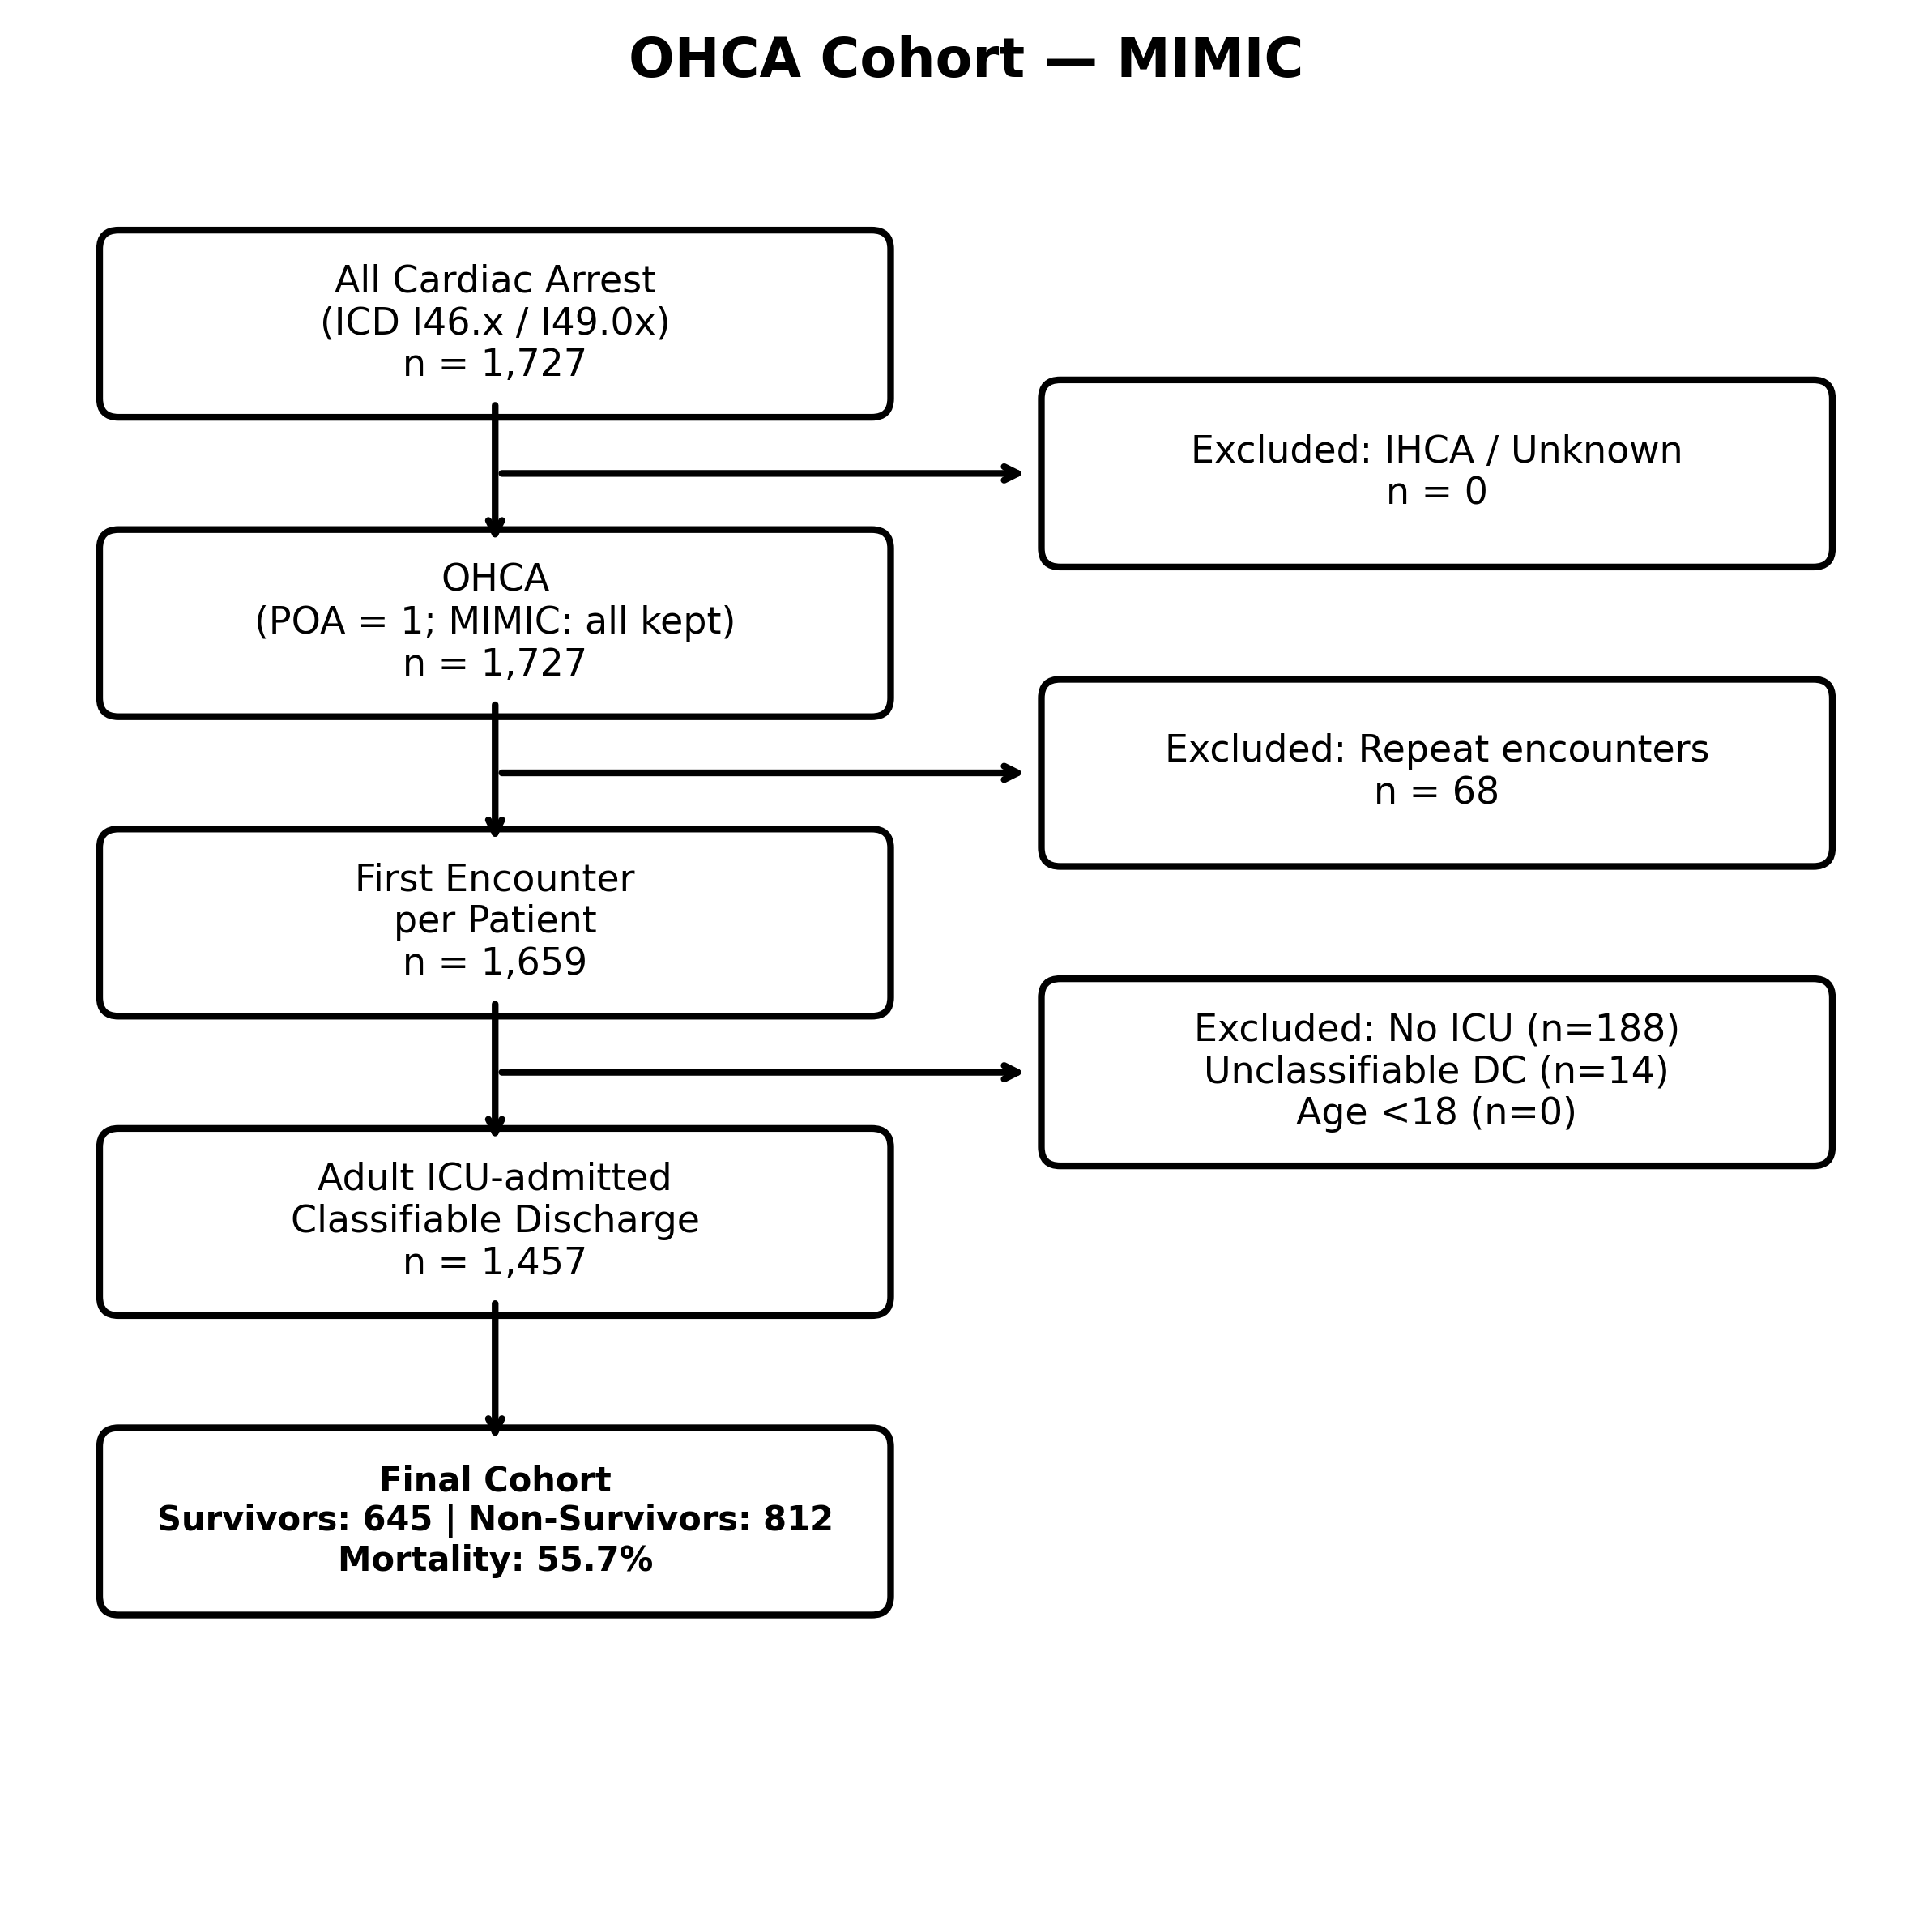

In [9]:
n_all_encounters = strobe_counts["1_all_cardiac_arrest_encounters"]
n_ohca           = strobe_counts["2_ohca_encounters"]
n_excluded_ihca  = strobe_counts["2_excluded_ihca_unknown"]
n_first          = strobe_counts["3_first_encounter_encounters"]
n_removed_repeat = strobe_counts["3_excluded_repeat_encounters"]
n_icu            = strobe_counts["4_icu_admitted_encounters"]
n_excl_no_icu    = strobe_counts["4_excluded_no_icu"]
n_excl_dc        = strobe_counts["4_excluded_unclassifiable_dc"]
n_excl_peds      = strobe_counts["4_excluded_pediatric"]
n_surv           = strobe_counts["4_survivors"]
n_died           = strobe_counts["4_non_survivors"]

stages = [
    f"All Cardiac Arrest\n(ICD I46.x / I49.0x)\nn = {n_all_encounters:,}",
    f"OHCA\n(POA = 1; MIMIC: all kept)\nn = {n_ohca:,}",
    f"First Encounter\nper Patient\nn = {n_first:,}",
    f"Adult ICU-admitted\nClassifiable Discharge\nn = {n_icu:,}",
]
drops = [
    f"Excluded: IHCA / Unknown\nn = {n_excluded_ihca:,}",
    f"Excluded: Repeat encounters\nn = {n_removed_repeat:,}",
    (f"Excluded: No ICU (n={n_excl_no_icu:,})\n"
     f"Unclassifiable DC (n={n_excl_dc:,})\n"
     f"Age <18 (n={n_excl_peds:,})"),
]

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

box_h, box_w = 0.08, 0.40
x_main_start, x_excl_start = 0.05, 0.55
x_main_center = x_main_start + box_w / 2
v_spacing = 0.16
excl_arrow_gap = 0.015

def draw_box(x, y, w, h, text, fontsize=11, weight="normal"):
    rect = FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.01",
        linewidth=2, edgecolor="black", facecolor="white",
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fontsize, fontweight=weight, color="black")

arrow_main = dict(arrowstyle="->", lw=2, color="black")

ax.text(0.5, 0.98, f"OHCA Cohort — {SITE_NAME.upper()}",
        ha="center", va="center", fontsize=16, fontweight="bold")

# Top stage
top_y = 0.88 - box_h
draw_box(x_main_start, top_y, box_w, box_h, stages[0])

# Successive stages
for i in range(len(drops)):
    y_parent = top_y - (i * v_spacing)
    y_curr   = top_y - ((i + 1) * v_spacing)
    arrow_mid = ((y_parent + box_h/2) + (y_curr + box_h/2)) / 2

    draw_box(x_main_start, y_curr, box_w, box_h, stages[i + 1])
    draw_box(x_excl_start, arrow_mid - box_h/2, box_w, box_h, drops[i])

    ax.annotate("", xy=(x_main_center, y_curr + box_h),
                xytext=(x_main_center, y_parent), arrowprops=arrow_main)
    ax.annotate("", xy=(x_excl_start - excl_arrow_gap, arrow_mid),
                xytext=(x_main_center, arrow_mid),
                arrowprops=dict(arrowstyle="->", lw=2, color="black"))

# Final outcomes box
final_y = top_y - (len(drops) * v_spacing) - v_spacing
mort_pct = n_died / n_icu * 100 if n_icu else 0
draw_box(x_main_start, final_y, box_w, box_h,
         f"Final Cohort\nSurvivors: {n_surv:,} | Non-Survivors: {n_died:,}\n"
         f"Mortality: {mort_pct:.1f}%",
         fontsize=10, weight="bold")

icu_box_y = top_y - (len(drops) * v_spacing)
ax.annotate("", xy=(x_main_center, final_y + box_h),
            xytext=(x_main_center, icu_box_y), arrowprops=arrow_main)

consort_path = FINAL_DIR / "consort_diagram.png"
fig.savefig(consort_path, dpi=300, bbox_inches="tight", facecolor="white")

# Save STROBE counts CSV
strobe_df = pd.DataFrame(list(strobe_counts.items()), columns=["counter", "value"])
strobe_df["site"] = SITE_NAME
strobe_df.to_csv(FINAL_DIR / "strobe_counts.csv", index=False)

print(f"Saved CONSORT diagram → {consort_path}")
print(f"Saved STROBE counts   → {FINAL_DIR / 'strobe_counts.csv'}")

# Display the figure inline
from IPython.display import Image, display
display(Image(filename=str(consort_path)))

In [11]:
# ── (a) Cohort parquet — read by notebook 01 ──
_save_cols = ["patient_id", "hospitalization_id", "diagnosis_code", "dx_clean",
              "poa_present", "arrest_type", "discharge_category", "survival_status",
              "icd_description", "age_at_admission"]
_existing  = [c for c in _save_cols if c in cohort_ohca_icu.columns]
cohort_save = cohort_ohca_icu[_existing].copy()
cohort_save["hospitalization_id"] = cohort_save["hospitalization_id"].astype(str)

# Bring admission_dttm in from the hospitalization table
_hosp_meta = con.execute(
    "SELECT hospitalization_id, admission_dttm FROM hosp_tbl"
).fetchdf()
_hosp_meta["hospitalization_id"] = _hosp_meta["hospitalization_id"].astype(str)
cohort_save = cohort_save.merge(_hosp_meta, on="hospitalization_id", how="left")

cohort_save.to_parquet(OUT_DIR / "cohort_ohca_icu.parquet", index=False)
print(f"Saved cohort  : {len(cohort_save):,} encounters → {OUT_DIR / 'cohort_ohca_icu.parquet'}")

# ── (b) Static patient-level df ──
# Demographics + age + outcome + death timing. Used by notebook 02+ for SOFA,
# table 1, and outcome regression.
_pat_df = pd.read_parquet(f"{TABLES_PATH}/clif_patient.parquet")
_pat_df["patient_id"] = _pat_df["patient_id"].astype(str)
print(f"clif_patient columns: {list(_pat_df.columns)}")

_hosp_extra = con.execute("""
    SELECT hospitalization_id, patient_id,
           admission_dttm, discharge_dttm, age_at_admission
    FROM hosp_tbl
""").fetchdf()
_hosp_extra["hospitalization_id"] = _hosp_extra["hospitalization_id"].astype(str)
_hosp_extra["patient_id"]         = _hosp_extra["patient_id"].astype(str)

_cohort_ids = cohort_ohca_icu[
    ["patient_id", "hospitalization_id", "discharge_category",
     "survival_status", "arrest_type"]
].drop_duplicates(subset=["hospitalization_id"]).copy()
_cohort_ids["hospitalization_id"] = _cohort_ids["hospitalization_id"].astype(str)
_cohort_ids["patient_id"]         = _cohort_ids["patient_id"].astype(str)

# Pull demographics only if those columns exist in MIMIC's patient table
_demo_cols = ["patient_id"]
for c in ["sex_category", "race_category", "ethnicity_category", "death_dttm"]:
    if c in _pat_df.columns:
        _demo_cols.append(c)

static_df = (_cohort_ids
    .merge(_hosp_extra[["hospitalization_id", "admission_dttm",
                        "discharge_dttm", "age_at_admission"]],
           on="hospitalization_id", how="left")
    .merge(_pat_df[_demo_cols], on="patient_id", how="left"))

# Set death_dttm: prefer clif_patient.death_dttm, fallback to discharge_dttm
# for expired/hospice patients. Clear it for non-expired patients (they may
# have died in a later hospitalization, which we don't want to attribute here).
if "death_dttm" in static_df.columns:
    _expired_mask = static_df["discharge_category"].str.lower().str.contains(
        "expired|hospice", na=False
    )
    static_df.loc[_expired_mask & static_df["death_dttm"].isna(), "death_dttm"] = (
        static_df.loc[_expired_mask & static_df["death_dttm"].isna(), "discharge_dttm"]
    )
    static_df.loc[~_expired_mask, "death_dttm"] = pd.NaT

# Normalize categorical strings
for _c in ["sex_category", "race_category", "ethnicity_category", "discharge_category"]:
    if _c in static_df.columns:
        static_df[_c] = static_df[_c].astype(str).str.lower().str.strip()

static_df.to_parquet(OUT_DIR / "patient_static.parquet", index=False)

print(f"\nSaved static  : {len(static_df):,} patients → {OUT_DIR / 'patient_static.parquet'}")
print(f"Columns saved : {list(static_df.columns)}")

# Quick demographics snapshot
print(f"\nDemographics quick-look:")
print(f"  Age   : median {static_df['age_at_admission'].median():.0f}, "
      f"IQR {static_df['age_at_admission'].quantile(0.25):.0f}–"
      f"{static_df['age_at_admission'].quantile(0.75):.0f}")
if "sex_category" in static_df.columns:
    print(f"  Sex   : {static_df['sex_category'].value_counts(dropna=False).to_dict()}")
if "race_category" in static_df.columns:
    print(f"  Race (top 5): {static_df['race_category'].value_counts().head(5).to_dict()}")
if "death_dttm" in static_df.columns:
    print(f"  Has death_dttm: {static_df['death_dttm'].notna().sum()} / {len(static_df)} "
          f"(expected ≈ non-survivors = {n_died})")

static_df.head()

Saved cohort  : 1,457 encounters → /home/yli94/CLIF/OHCA-RL/output/intermediate/cohort_ohca_icu.parquet
clif_patient columns: ['patient_id', 'race_name', 'race_category', 'ethnicity_name', 'ethnicity_category', 'sex_name', 'sex_category', 'birth_date', 'death_dttm', 'language_name', 'language_category']

Saved static  : 1,457 patients → /home/yli94/CLIF/OHCA-RL/output/intermediate/patient_static.parquet
Columns saved : ['patient_id', 'hospitalization_id', 'discharge_category', 'survival_status', 'arrest_type', 'admission_dttm', 'discharge_dttm', 'age_at_admission', 'sex_category', 'race_category', 'ethnicity_category', 'death_dttm']

Demographics quick-look:
  Age   : median 68, IQR 56–78
  Sex   : {'male': 915, 'female': 542}
  Race (top 5): {'white': 749, 'unknown': 374, 'black or african american': 186, 'other': 95, 'asian': 38}
  Has death_dttm: 847 / 1457 (expected ≈ non-survivors = 812)


,patient_id,hospitalization_id,discharge_category,survival_status,arrest_type,admission_dttm,discharge_dttm,age_at_admission,sex_category,race_category,ethnicity_category,death_dttm
0,10321613,20186322,expired,non-survivor,ohca,2160-01-17 06:14:00-05:00,2160-01-21 15:45:00-05:00,76,male,white,non-hispanic,2160-01-21 20:45:00+00:00
1,10438253,29269604,skilled nursing facility (snf),survivor,ohca,2112-05-01 13:58:00-05:00,2112-05-07 15:13:00-05:00,67,male,white,non-hispanic,NaT
2,10440899,26609648,long term care hospital (ltach),survivor,ohca,2145-03-17 22:13:00-05:00,2145-05-28 14:00:00-05:00,62,female,unknown,unknown,NaT
3,10453833,21676306,expired,non-survivor,ohca,2167-07-20 00:48:00-05:00,2167-07-24 02:48:00-05:00,77,male,white,non-hispanic,2167-07-24 07:48:00+00:00
4,10682399,23950803,expired,non-survivor,ohca,2112-11-04 14:00:00-05:00,2112-11-30 10:45:00-05:00,69,male,white,non-hispanic,2112-11-30 15:45:00+00:00
